# Notebook 11: Handcrafted Features Autoencoder

## Objective
In Notebook 10, we reproduced the original MIMII Autoencoder baseline using Log-Mel Spectrogram features. While the baseline demonstrated moderate anomaly detection performance, it relied on generic spectral representations without considering feature relevance for the target machine.

In previous notebooks, an extensive feature engineering and feature selection pipeline was developed to identify the most informative handcrafted acoustic features for the Pump `id_00` dataset. These selected features capture complementary characteristics of machine sounds, including temporal, spectral, and perceptual information.

The objective of this notebook is to investigate whether these handcrafted features can improve anomaly detection performance while keeping the Autoencoder architecture and training protocol unchanged.

By fixing the model architecture and modifying only the input representation, this experiment isolates the contribution of feature engineering to the overall system performance.

## Research Question

**Can carefully selected handcrafted acoustic features improve reconstruction-based anomaly detection compared to the Log-Mel Spectrogram baseline?**


## Experimental Design

To ensure a fair comparison with Notebook 10, all experimental settings remain identical except for the input features.

| Component | Notebook 10 | Notebook 11 |
|----------|-------------|-------------|
| Input Features | Log-Mel Spectrogram | Selected Handcrafted Features |
| Autoencoder Architecture | Same | Same |
| Loss Function | Mean Squared Error | Mean Squared Error |
| Optimizer | Adam | Adam |
| Epochs | 50 | 50 |
| Evaluation Protocol | Reconstruction Error | Reconstruction Error |

---

## Expected Outcome

If the handcrafted features better represent normal machine behaviour, the Autoencoder should learn a more compact representation of normal operating conditions. Consequently, abnormal recordings are expected to produce larger reconstruction errors, leading to improved separation between normal and abnormal samples.

The resulting performance will be directly compared with the Log-Mel baseline from Notebook 10 to quantify the impact of feature engineering.

---

## Notebook Structure

1. Load Selected Features
2. Dataset Preparation
3. Autoencoder Model
4. Model Training
5. Model Evaluation
6. Baseline Comparison

In [1]:
%load_ext autoreload
%autoreload 2

### Imports

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from src.config import *
from src.models import *
from src.utils import *
from src.visualization import *

In [4]:
set_seed(random_seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device : {device}")
print(f"Random Seed : {random_seed}")

Using Device : cuda
Random Seed : 42


In [5]:
# Experiment configuration
CONFIG = {
    "batch_size": 32,
    "epochs": 50,
    "learning_rate": 1e-3,
    "hidden_dim": 64,
    "latent_dim": 3
}
print("Experiment Configuration")
for key, value in CONFIG.items():
    print(f"{key:15}: {value}")

Experiment Configuration
batch_size     : 32
epochs         : 50
learning_rate  : 0.001
hidden_dim     : 64
latent_dim     : 3


## Part 2  - Dataset Preparation

### Load Dataset

In [6]:
feature_dataset = pd.read_csv(results_path/"selected_features.csv")
print(f"Dataset Shape : {feature_dataset.shape}")
feature_dataset.head()

Dataset Shape : (1149, 12)


,file_name,label,Research_Group,rms,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_5_std,mfcc_8_mean,centroid_std,centroid_iqr
0,00000000.wav,Normal,Normal,0.006863,-285.32410,13.046962,61.081543,8.571634,6.616282,1.595431,203.249647,252.325257
1,00000001.wav,Normal,Normal,0.006892,-282.27840,10.958236,51.239525,7.887704,7.068424,-0.574502,163.012387,196.780913
2,00000002.wav,Normal,Normal,0.007001,-284.63037,13.951112,60.277317,10.349363,6.943223,2.044545,221.444349,277.055284
3,00000003.wav,Normal,Normal,0.006864,-284.53845,11.082034,51.455030,7.180773,5.265297,3.684129,143.981090,175.194813
4,00000004.wav,Normal,Normal,0.006833,-281.46950,10.882649,63.417408,7.536225,5.741307,1.347923,161.885214,178.263960


In [7]:
feature_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   file_name       1149 non-null   object 
 1   label           1149 non-null   object 
 2   Research_Group  1149 non-null   object 
 3   rms             1149 non-null   float64
 4   mfcc_1_mean     1149 non-null   float64
 5   mfcc_1_std      1149 non-null   float64
 6   mfcc_2_mean     1149 non-null   float64
 7   mfcc_2_std      1149 non-null   float64
 8   mfcc_5_std      1149 non-null   float64
 9   mfcc_8_mean     1149 non-null   float64
 10  centroid_std    1149 non-null   float64
 11  centroid_iqr    1149 non-null   float64
dtypes: float64(9), object(3)
memory usage: 107.8+ KB


### Separating Metadata and Features

In [8]:
metadata_columns = ["file_name", "label", "Research_Group"]
feature_columns = [column for column in feature_dataset.columns 
                   if column not in metadata_columns
                  ]
print(f"Number of Selected Features: {len(feature_columns)}")
feature_columns

Number of Selected Features: 9


['rms',
 'mfcc_1_mean',
 'mfcc_1_std',
 'mfcc_2_mean',
 'mfcc_2_std',
 'mfcc_5_std',
 'mfcc_8_mean',
 'centroid_std',
 'centroid_iqr']

### Train/Test Split

In [9]:
normal_df = feature_dataset[feature_dataset["label"] == "Normal"].copy()
abnormal_df = feature_dataset[feature_dataset["label"] == "Abnormal"].copy()

# randomly select normal recordings for evaluation
test_normal_df = normal_df.sample(
    n = len(abnormal_df), random_state = random_seed
)
# remaining normal recordings for training
train_df = normal_df.drop(test_normal_df.index)
# Evaluation set
test_df = pd.concat([test_normal_df, abnormal_df], ignore_index = True)

print(f"Training Recordings : {len(train_df)}")
print(f"Evaluation Recordings : {len(test_df)}")

print("\nEvaluation Label Distribution")
print(test_df["label"].value_counts())

Training Recordings : 863
Evaluation Recordings : 286

Evaluation Label Distribution
label
Normal      143
Abnormal    143
Name: count, dtype: int64


### Creating Official Experiment Split

In [10]:
train_split = train_df[["file_name", "label", "Research_Group"]].copy()
train_split["split"] = "train"
test_split = test_df[["file_name", "label", "Research_Group"]].copy()
test_split["split"] = "test"
experiment_split = pd.concat([train_split, test_split], ignore_index = True)
experiment_split.head()

,file_name,label,Research_Group,split
0,00000000.wav,Normal,Normal,train
1,00000001.wav,Normal,Normal,train
2,00000002.wav,Normal,Normal,train
3,00000003.wav,Normal,Normal,train
4,00000004.wav,Normal,Normal,train


In [10]:
experiment_split.to_csv(results_path/"experiment_split.csv", index = False)
print("Experiment split saved successfully.")

Experiment split saved successfully.


### Prepare Feature Matrices

In [11]:
x_train = train_df[feature_columns].to_numpy(dtype = np.float32)
x_test = test_df[feature_columns].to_numpy(dtype = np.float32)
y_test = (test_df["label"] == "Abnormal").astype(int).to_numpy()
research_groups = test_df["Research_Group"].to_numpy()

In [12]:
# Feature Standardization
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [13]:
import joblib

joblib.dump(
    scaler,
    os.path.join(results_path, "models", "feature_scaler.pkl")
)

['C:\\MyProjects\\MIMIIResearch\\EchoGuard\\results\\models\\feature_scaler.pkl']

In [13]:
# Verification
print("Training Feature Matrix :", x_train.shape)
print("Evaluation Feature Matrix :", x_test.shape)
print("\nTraining Labels")
print(train_df["label"].value_counts())
print("\nEvaluation Labels")
print(test_df["label"].value_counts())
print("\nResearch Groups in Evaluation Set")
print(test_df["Research_Group"].value_counts())

Training Feature Matrix : (863, 9)
Evaluation Feature Matrix : (286, 9)

Training Labels
label
Normal    863
Name: count, dtype: int64

Evaluation Labels
label
Normal      143
Abnormal    143
Name: count, dtype: int64

Research Groups in Evaluation Set
Research_Group
Normal     143
Obvious     96
Overlap     47
Name: count, dtype: int64


# Part 3 - Autoencoder Model


To isolate the effect of handcrafted feature engineering, the Autoencoder architecture remains identical to the baseline implementation presented in Notebook 10.

The only difference is the input dimension, which is determined by the number of selected handcrafted features rather than the 320-dimensional Log-Mel representation.

This ensures that any performance difference can be attributed to the feature representation rather than changes in the model architecture.

### Input dimension

In [14]:
input_dim = x_train.shape[1]
print(f"input Dimension : {input_dim}")

input Dimension : 9


### Initialize Model

In [15]:
model = Autoencoder(
    input_dim = input_dim,
    hidden_dim = CONFIG["hidden_dim"],
    latent_dim = CONFIG["latent_dim"]
).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=9, bias=True)
  )
)


In [16]:
# Model Summary
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 9,996
Trainable Parameters : 9,996


### Loss Function and Optimizer

In [17]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr = CONFIG["learning_rate"])
print("Loss Function: ", criterion)
print("Optimizer: Adam")

Loss Function:  MSELoss()
Optimizer: Adam


# Part 4 - Model Training

### Training and Validation split

In [18]:
from sklearn.model_selection import train_test_split
x_train_final, x_val = train_test_split(
    x_train,
    test_size=0.10,
    random_state=random_seed,
    shuffle=True
)
print(f"Training Samples   : {len(x_train_final)}")
print(f"Validation Samples : {len(x_val)}")

Training Samples   : 776
Validation Samples : 87


### DataLoaders

In [19]:
train_dataset = torch.tensor(
    x_train_final,
    dtype=torch.float32
)
val_dataset = torch.tensor(
    x_val,
    dtype=torch.float32
)
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False
)

### Training Loop

In [20]:
train_losses = []
val_losses = []

for epoch in range(CONFIG["epochs"]):
    # Training
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            reconstruction = model(batch)
            loss = criterion(reconstruction, batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{CONFIG['epochs']} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f}"
    )

Epoch 01/50 | Train Loss: 0.900814 | Validation Loss: 1.780362
Epoch 02/50 | Train Loss: 0.733721 | Validation Loss: 1.051854
Epoch 03/50 | Train Loss: 0.595622 | Validation Loss: 0.981856
Epoch 04/50 | Train Loss: 0.546566 | Validation Loss: 0.867188
Epoch 05/50 | Train Loss: 0.477869 | Validation Loss: 0.728367
Epoch 06/50 | Train Loss: 0.355355 | Validation Loss: 0.616388
Epoch 07/50 | Train Loss: 0.318761 | Validation Loss: 0.568156
Epoch 08/50 | Train Loss: 0.290648 | Validation Loss: 0.584105
Epoch 09/50 | Train Loss: 0.279070 | Validation Loss: 0.548162
Epoch 10/50 | Train Loss: 0.274003 | Validation Loss: 0.542844
Epoch 11/50 | Train Loss: 0.272698 | Validation Loss: 0.554333
Epoch 12/50 | Train Loss: 0.265972 | Validation Loss: 0.569558
Epoch 13/50 | Train Loss: 0.262661 | Validation Loss: 0.545830
Epoch 14/50 | Train Loss: 0.256385 | Validation Loss: 0.564651
Epoch 15/50 | Train Loss: 0.256413 | Validation Loss: 0.569437
Epoch 16/50 | Train Loss: 0.256271 | Validation Loss: 0

### Training Loss Curve

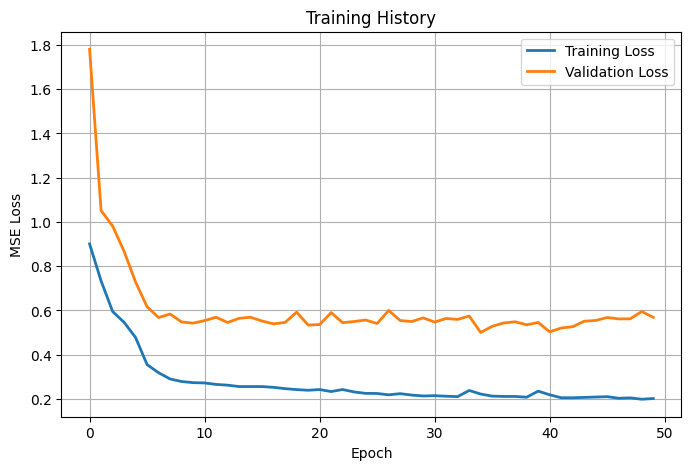

In [21]:
plt.figure(figsize=(8,5))
plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2
)
plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2
)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
torch.save(model.state_dict(), results_path/"models"/"handcrafted_autoencoder.pth")
print("Model saved successfully.")

Model saved successfully.


In [42]:
torch.save(model, results_path/"models"/"handcrafted_autoencoder_full.pth")
print("Model saved successfully.")

Model saved successfully.


### Why changing the latent dimension from 8 -> 3

Because the handcrafted feature representation consists of only nine input features, the latent dimension was adjusted from 8 to 3. This adaptation maintains a non-trivial compression bottleneck while leaving the overall encoder–decoder architecture and training procedure unchanged. Thus, the primary experimental variable remains the input feature representation, with only the bottleneck size adapted to account for the substantially lower input dimensionality.

# Part 5 - Model Evaluation

### Reconstruction errors

In [33]:
model.eval()
x_test_tensor = torch.tensor(
    x_test,
    dtype=torch.float32
).to(device)
with torch.no_grad():
    reconstruction = model(x_test_tensor)
    reconstruction_error = torch.mean(
        (x_test_tensor - reconstruction) ** 2,
        dim=1
    ).cpu().numpy()
    
print(f"Computed anomaly scores for {len(reconstruction_error)} recordings.")
print(reconstruction_error.mean())
print(reconstruction_error.std())
threshold = reconstruction_error.mean() + 3 * reconstruction_error.std()
print(threshold)


Computed anomaly scores for 286 recordings.
6.361124
11.536765
40.97141933441162


### ROC-AUC

In [34]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    reconstruction_error
)
auc_score = roc_auc_score(
    y_test,
    reconstruction_error
)
print(f"ROC-AUC : {auc_score:.4f}")

ROC-AUC : 0.9681


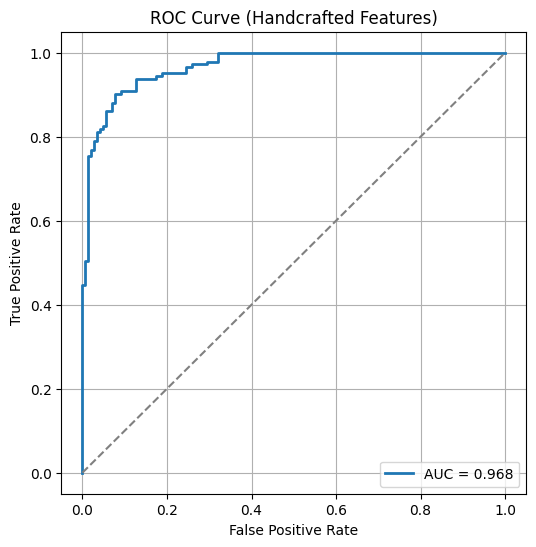

In [35]:
plt.figure(figsize=(6,6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc_score:.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Handcrafted Features)")
plt.legend()
plt.grid(True)
plt.savefig(results_path /"figures"/"handcrafted_features_autoencoder"/
            "roc-curve.png",
    dpi=150
)
plt.show()

### Score Distribution

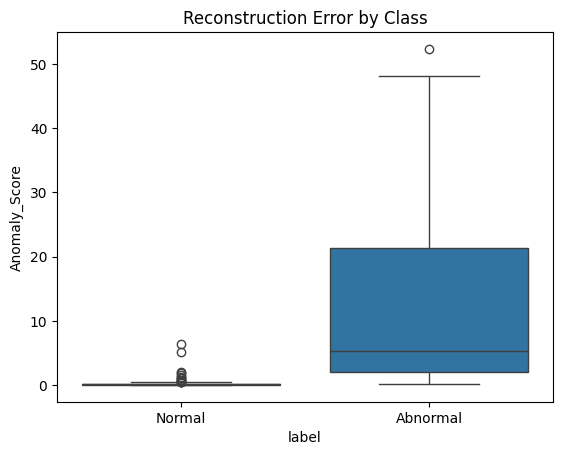

In [36]:
# Reconstruction Error Distribution
results_df = test_df.copy()
results_df["Anomaly_Score"] = reconstruction_error
sns.boxplot(data = results_df, x = "label", y = "Anomaly_Score")
plt.title("Reconstruction Error by Class")
plt.show()

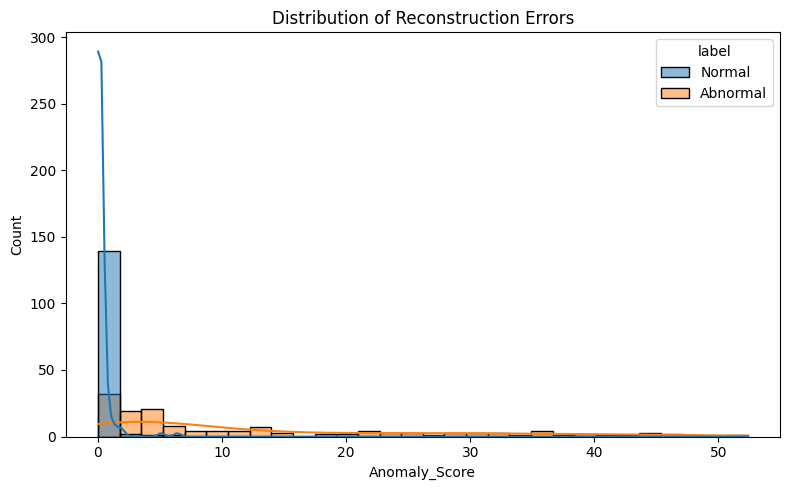

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=results_df,
    x="Anomaly_Score",
    hue="label",
    kde=True,
    bins=30
)

plt.title("Distribution of Reconstruction Errors")
plt.tight_layout()
plt.savefig(results_path /"figures"/"handcrafted_features_autoencoder"/
            "error_distribution.png",
    dpi=150
)

plt.show()

### Research Group Analysis

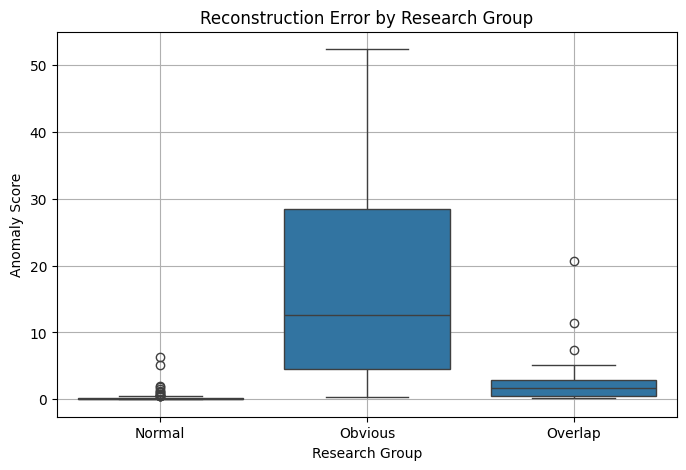

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=results_df,
    x="Research_Group",
    y="Anomaly_Score"
)
plt.title("Reconstruction Error by Research Group")
plt.xlabel("Research Group")
plt.ylabel("Anomaly Score")
plt.grid(True)
plt.savefig(results_path /"figures"/"handcrafted_features_autoencoder"/
            "error_research_group.png",
    dpi=150
)

plt.show()

# Part 6 - Baseline Comparison

This experiment evaluates the effect of replacing the Log-Mel Spectrogram representation used in the original MIMII Autoencoder baseline with the selected handcrafted acoustic features developed in previous notebooks.

To ensure a fair comparison, the Autoencoder architecture, optimizer, loss function, training procedure and evaluation protocol were kept identical to the baseline. the only methodological adaptation was reducing the latent dimension from **8 to 3** to maintain a meaningful compression bottleneck for the 9-dimensional handcrafted feature vector.

The comparison therefore isolates the effect of the input feature representation on anomaly detection performance

### Comparison Table

In [39]:
#### Baseline Comparison
comparison = pd.DataFrame({

    "Metric": [
        "Input Features",
        "Input Dimension",
        "Latent Dimension",
        "ROC-AUC"
    ],
    "Log-Mel Baseline": [
        "Log-Mel Spectrogram",
        320,
        8,
        0.6994
    ],
    "Handcrafted Features": [
        "Selected Features",
        input_dim,
        CONFIG["latent_dim"],
        round(auc_score, 4)
    ]
})
comparison

,Metric,Log-Mel Baseline,Handcrafted Features
0,Input Features,Log-Mel Spectrogram,Selected Features
1,Input Dimension,320,9
2,Latent Dimension,8,3
3,ROC-AUC,0.6994,0.9681


In [40]:
# Performance Improvement
baseline_auc = 0.6994
improvement = auc_score - baseline_auc
relative_improvement = (
    improvement / baseline_auc
) * 100

print(f"Baseline ROC-AUC      : {baseline_auc:.4f}")
print(f"Handcrafted ROC-AUC   : {auc_score:.4f}")
print()
print(f"Absolute Improvement  : {improvement:.4f}")
print(f"Relative Improvement  : {relative_improvement:.2f}%")

Baseline ROC-AUC      : 0.6994
Handcrafted ROC-AUC   : 0.9681

Absolute Improvement  : 0.2687
Relative Improvement  : 38.41%


### ROC Comparison

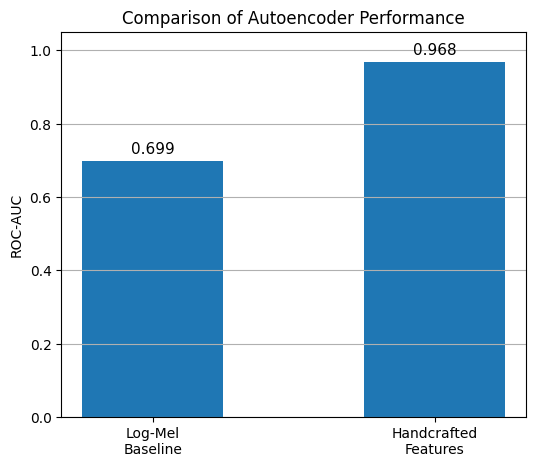

In [41]:
plt.figure(figsize=(6,5))
models = [
    "Log-Mel\nBaseline",
    "Handcrafted\nFeatures"
]
scores = [
    baseline_auc,
    auc_score
]
bars = plt.bar(
    models,
    scores,
    width=0.5
)
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.05)
plt.title("Comparison of Autoencoder Performance")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha="center",
        fontsize=11
    )
plt.grid(axis="y")
plt.savefig(results_path /"figures"/"handcrafted_features_autoencoder"/
            "performance_comparison.png",
    dpi=150
)

plt.show()

## Observations

- Replacing the Log-Mel representation with the selected handcrafted acoustic features resulted in a substantial improvement in anomaly detection performance.

- The ROC-AUC increased from **0.69** to **0.96**, indicating significantly better discrimination between normal and abnormal machine sounds.

- Normal recordings formed a compact low-error distribution, demonstrating that the Autoencoder learned an accurate representation of normal operating behaviour.

- Obvious anomalies produced consistently high reconstruction errors.

- The most significant improvement was observed for the **Overlap** group, where many subtle anomalies that were poorly separated in the baseline experiment became distinguishable from normal recordings.

Overall, these results indicate that the choice of feature representation has a major influence on reconstruction-based anomaly detection performance for the Pump `id_00` subset of the MIMII dataset.